In [1]:

import os
import scipy.io
import h5py
import numpy as np
import sys
from scipy import signal as sig
from scipy import stats as stats
import math
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
import logging

%matplotlib widget

scripts_path = '/home/apolo/Documents/github_projects/ripple_sync/scripts/hc_11_scripts/'
os.chdir(scripts_path)

import hc11_BaseFunctions as hc11_bf

scripts_path = '/home/apolo/Documents/github_projects/ripple_sync/scripts/hc_18_scripts/'
os.chdir(scripts_path)

import hc18_BaseFunctions as hc18_bf
import smoothing_functions as smooth
import normalizing_functions as norm

sessions = ['Train-242-20140124','Train-261-20140617','Train-272-20141215','Train-292-20150501','Train-314-20160118']
animals = ['242','261','272','292','314']


In [2]:
session = sessions[4]

In [3]:
event_name = 'SleepBaseline'
# event_name = 'PassiveForward'
    
srate = 1250.

lfp,srate = hc18_bf.load_lfp_hc18_data(session)

event_times, event_descriptions = hc18_bf.get_events(session, event_name)

event_times = np.sort(np.array(event_times))
event_start = np.nanmin(event_times)
event_end = np.nanmax(event_times)

shanks_electrodes,left_shanks,right_shanks = hc18_bf.get_shanks_info(session)


In [4]:

lfp_index = np.round(np.arange(event_start*srate,event_end*srate)).astype(int)
lfp = np.double(lfp[:,lfp_index])
lfp = sig.detrend(hc11_bf.eegfilt(lfp,srate,0.1,0))


In [5]:

theta_filtered = sig.detrend(hc11_bf.eegfilt(lfp[:,0:int(5*60*srate)],srate,5,12))
theta_hilbert = hc11_bf.hilbert(theta_filtered)
theta_amp = np.abs(theta_hilbert)


In [6]:
np.argsort(np.nanmean(theta_amp,1))

array([ 79,  66,  74,  48, 118, 116, 113, 114, 119,  14,  67, 117, 115,
        12, 112,  18,  16,  11,  59,  76,  60,  68,  22,  65,  69,  70,
        71,  61,  64,  53,  63,  75,  62,  15,  36,  52,  49,  77,  19,
        78,  73,  72,  54,  20,  10,  55,  32,  13,  58,  51,  21,  50,
        56,  34,   9,   8,  45,  47,  40,  57,  17,  42,  91,  43,  46,
        41,  37,  80,  85,  86,  87,  44,  88,  83,  92,  84,  90,  23,
        35,  98,  33, 100,  94,  93,  95, 102, 103, 101,  82,  96,  97,
        99,  38,   6,   4,  81,   2,  89,  39,   1,   7,   5,   0,   3,
        30,  31,  24,  29,  27,  25,  26,  28, 120, 122, 123, 124, 125,
       126, 121, 127, 105, 104, 111, 106, 110, 108, 109, 107])

In [7]:
np.sort(np.nanmean(theta_amp,1))

array([ 99.72519282, 122.65626764, 187.6393186 , 187.92969596,
       190.73644191, 192.00323345, 192.15481503, 192.7975882 ,
       194.94973102, 194.9822551 , 196.02988894, 196.53235271,
       197.1535658 , 197.62114194, 200.14368144, 202.75614039,
       205.00502267, 206.46452927, 207.56793193, 208.36559124,
       209.18772403, 210.31345688, 211.56090892, 212.32272788,
       213.4254241 , 214.15336978, 214.43520748, 219.1742133 ,
       219.40600759, 220.43644632, 220.92140915, 221.47748082,
       221.69945724, 222.28340669, 224.34874435, 224.70434375,
       225.774915  , 228.9165988 , 229.86346618, 230.47323318,
       230.84185263, 230.93078721, 231.50670486, 236.34888044,
       237.88801787, 243.65778488, 245.32900302, 250.53163033,
       251.31426043, 252.26785034, 252.68531717, 254.38869784,
       254.94863197, 255.50629813, 255.84290004, 257.91431443,
       259.46182156, 263.72360525, 264.05168468, 265.23482086,
       266.23539479, 269.11102874, 272.31944441, 275.21

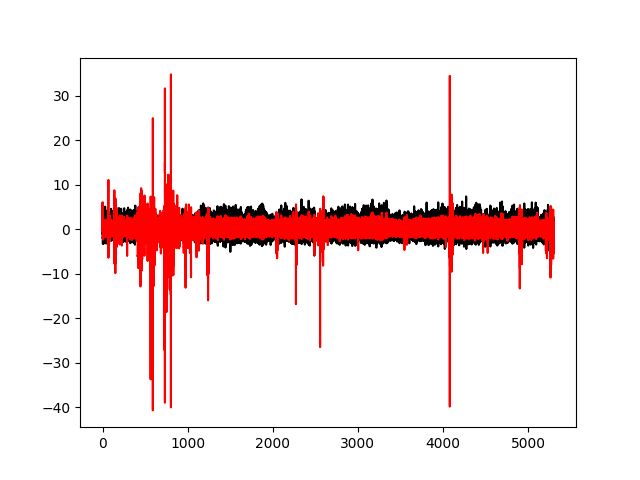

In [9]:

plt.figure()

ch = 44
lfp_norm = sig.detrend(norm.z_score_norm(lfp[ch,:]))
time_vector = np.linspace(0,lfp_norm.shape[0]/srate,lfp_norm.shape[0])

plt.plot(time_vector,lfp_norm,'k')

ch = 79
lfp_norm = sig.detrend(norm.z_score_norm(lfp[ch,:]))
time_vector = np.linspace(0,lfp_norm.shape[0]/srate,lfp_norm.shape[0])

plt.plot(time_vector,lfp_norm,'r')

plt.show()


In [10]:

ch = 44
lfp_norm = sig.detrend(norm.z_score_norm(lfp[ch,:]))

delta_filtered = sig.detrend(hc11_bf.eegfilt(lfp_norm,srate,0,4))
delta_hilbert = hc11_bf.hilbert(delta_filtered)
delta_amp = np.abs(delta_hilbert)

theta_filtered = sig.detrend(hc11_bf.eegfilt(lfp_norm,srate,5,12))
theta_hilbert = hc11_bf.hilbert(theta_filtered)
theta_amp = np.abs(theta_hilbert)

time_vector = np.linspace(0,lfp_norm.shape[0]/srate,lfp_norm.shape[0])


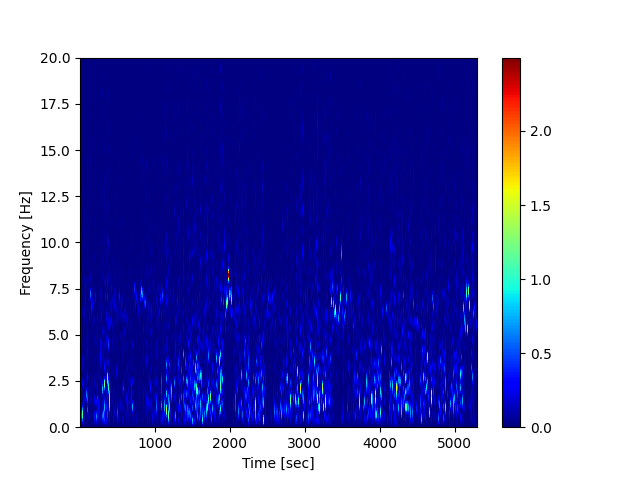

In [12]:
window = int(2*srate)
f, t, Sxx = sig.spectrogram(lfp_norm, fs=srate, window=('tukey', 0.25), nperseg=window, noverlap=window/2, nfft=2**14, detrend='constant', return_onesided=True, scaling='density', axis=-1, mode='psd')

plt.figure()
# plt.pcolormesh(t, fftshift(f), fftshift(Sxx, axes=0), shading='gouraud')
plt.pcolormesh(t, f, Sxx, cmap='jet')
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.ylim([0,20])
plt.show()


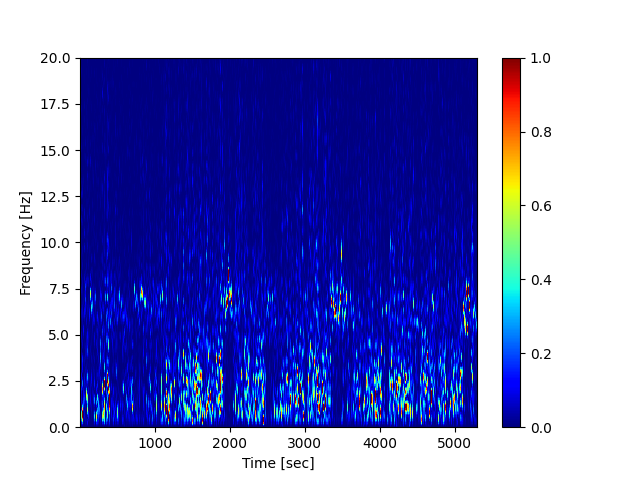

In [13]:
plt.figure()
# plt.pcolormesh(t, fftshift(f), fftshift(Sxx, axes=0), shading='gouraud')
plt.pcolormesh(t, f, Sxx, cmap='jet')
plt.colorbar()
plt.clim([0,1])
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.ylim([0,20])
plt.show()


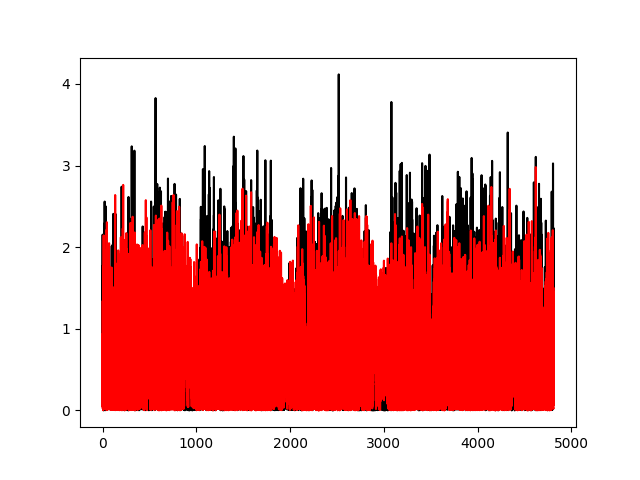

In [24]:

plt.figure()
plt.plot(time_vector,delta_amp,'k')
plt.plot(time_vector,theta_amp,'r')
plt.show()


In [14]:

amp_window_length = 5.0*srate
non_overlap = 1.0*srate
overlap = amp_window_length-non_overlap
binned_delta_amplitude = []
binned_theta_amplitude = []
binned_time_vector = []
for ll in np.arange(0,((lfp_norm.shape[0]-amp_window_length)/non_overlap)):
    amp_window = np.arange((amp_window_length-overlap)*ll,(amp_window_length-overlap)*ll + amp_window_length).astype(int)

    binned_delta_amplitude.append(np.nanmean(delta_amp[amp_window]))
    binned_theta_amplitude.append(np.nanmean(theta_amp[amp_window]))
    binned_time_vector.append(np.nanmedian(time_vector[amp_window]))

binned_delta_amplitude = np.array(binned_delta_amplitude)
binned_theta_amplitude = np.array(binned_theta_amplitude)
binned_time_vector = np.array(binned_time_vector)


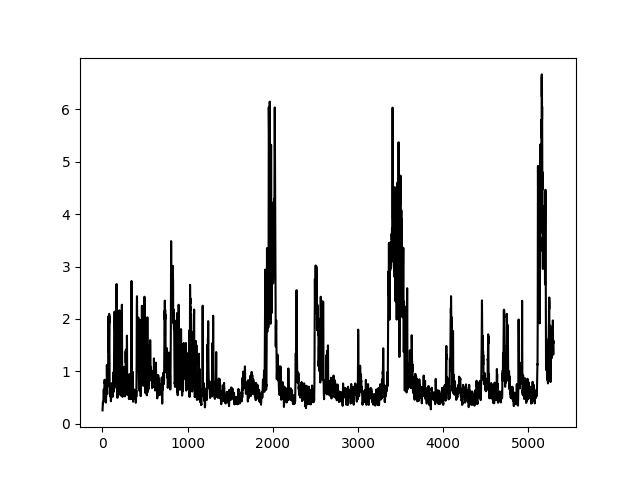

In [15]:

plt.figure()
plt.plot(binned_time_vector,binned_theta_amplitude/binned_delta_amplitude,'k')
plt.show()


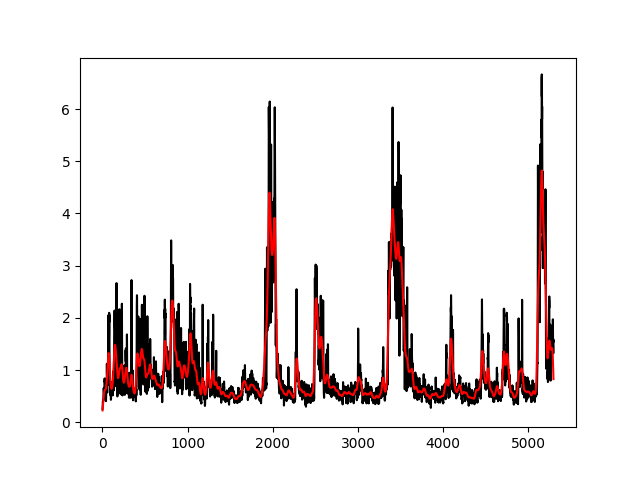

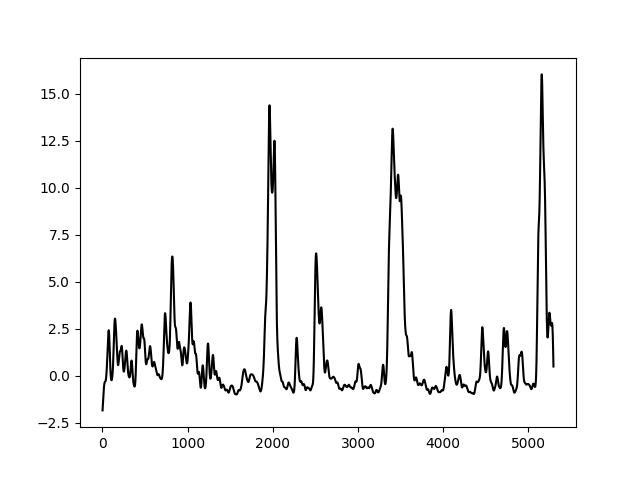

In [16]:
sigma = 10
sigma_points = smooth.get_sigma_points(sigma,binned_time_vector)
kernel, x_values = smooth.generate_1d_gaussian_kernel(sigma_points)

theta_delta_ratio = binned_theta_amplitude/binned_delta_amplitude
theta_delta_ratio_smoothed = smooth.gaussian_smooth_1d(theta_delta_ratio,kernel)

plt.figure()
plt.plot(binned_time_vector,theta_delta_ratio,'k')
plt.plot(binned_time_vector,theta_delta_ratio_smoothed,'r')
plt.show()

theta_delta_ratio_smoothed_norm = norm.robust_z_score_norm(theta_delta_ratio_smoothed)

plt.figure()
plt.plot(binned_time_vector,theta_delta_ratio_smoothed_norm,'k')
plt.show()


In [17]:
threshold = 1
theta_index = np.where(theta_delta_ratio_smoothed > threshold)[0]
theta_blocks = hc18_bf.split_into_contiguous_blocks(theta_index)

theta_epochs = []
for theta_block in theta_blocks:
    theta_start = theta_block[0]
    theta_end = theta_block[-1]
    theta_block_idx = np.where((time_vector >= binned_time_vector[theta_start]) & (time_vector <= binned_time_vector[theta_end]))[0]
    theta_epochs.append(theta_block_idx)
theta_epochs = np.unique(np.concatenate(theta_epochs))
sws_epochs = np.delete(np.arange(time_vector.shape[0]),theta_epochs)


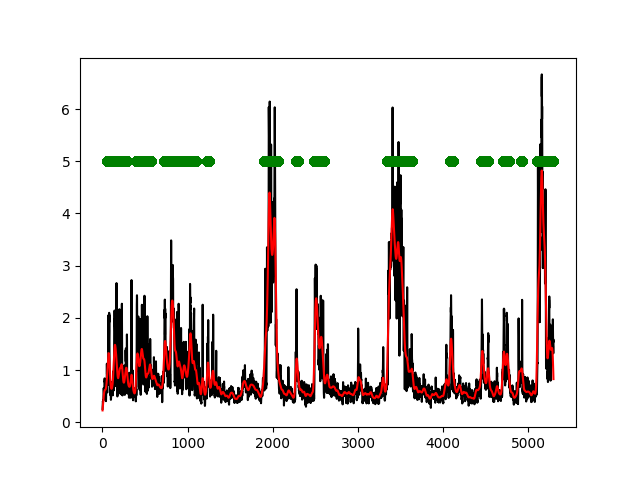

In [18]:

plt.close('all')
plt.figure()
plt.plot(binned_time_vector,theta_delta_ratio,'k')
plt.plot(binned_time_vector,theta_delta_ratio_smoothed,'r')
plt.plot(time_vector[theta_epochs],5*np.ones(theta_epochs.shape[0]),'go')
plt.show()


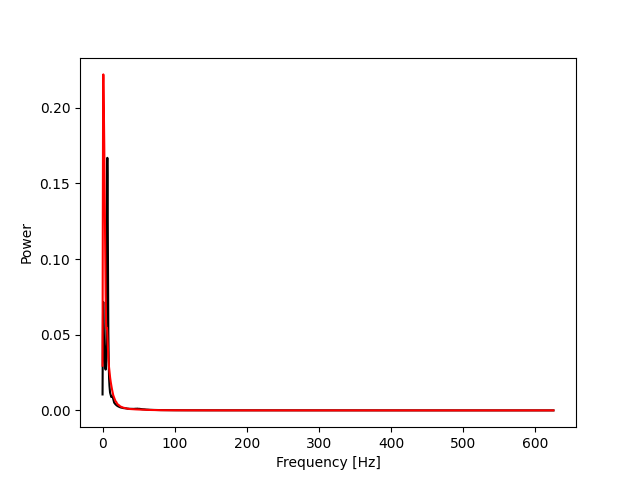

In [19]:

window = 2*srate
f, Pxx_theta = sig.welch(lfp_norm[theta_epochs], fs=srate, window='hann', nperseg=window, noverlap=window/2, nfft=2**14, detrend='constant', return_onesided=True, scaling='density', axis=-1, average='mean')
f, Pxx_delta = sig.welch(lfp_norm[sws_epochs], fs=srate, window='hann', nperseg=window, noverlap=window/2, nfft=2**14, detrend='constant', return_onesided=True, scaling='density', axis=-1, average='mean')

plt.figure()
plt.plot(f, Pxx_theta, 'k')
plt.plot(f, Pxx_delta, 'r')

plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.show()


In [20]:
sws_epochs.shape[0]/srate/60

63.434999999999995

In [21]:
theta_epochs.shape[0]/srate/60

24.85

In [22]:
filename = f'{scripts_path}/{session}_{event_name}_sleep_epochs.npy' 
sleep_dict = {'sws_epochs':sws_epochs,'theta_epochs':theta_epochs}
np.save(filename,sleep_dict)


In [2]:
sleep_epochs = np.load(filename,allow_pickle=True).item()
sleep_epochs

NameError: name 'np' is not defined

In [1]:
sleep_epochs['sws_epochs']

NameError: name 'sleep_epochs' is not defined

In [24]:
np.intersect1d(sws_epochs,theta_epochs)

array([], dtype=int64)